# RNA-seq analysis tutorial: how does Zika virus change gene expression in neural progenitors?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/BioProteanLabs/Tutorials/blob/main/ZikaRNAseq/ZikaRNAseq.ipynb)

Adapted from *An Open RNA-Seq Data Analysis Pipeline Tutorial with an Example of Reprocessing Data from a Recent Zika Virus Study* by Zichen Wang and Avi Ma'ayan (Icahn School of Medicine at Mount Sinai). The original Docker-based version is in the source repository's `legacy/` folder.

## The data

Human neural progenitor cells were either mock-treated or infected with Zika virus (ZIKV) and sequenced with RNA-seq ([Tang et al. 2016](https://pubmed.ncbi.nlm.nih.gov/26952870/), GEO [GSE78711](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE78711)). There are 8 samples: 2 mock and 2 infected on each of two sequencing machines (MiSeq and NextSeq 500).

The raw reads have already been aligned and counted for you: `data/count_matrix.csv` holds the number of reads per gene per sample (NCBI's standard GRCh38 processing of the GEO series). You do not need to handle any sequencing files in this class.

## What you will do

1. Load and normalize the counts
2. Explore sample similarity with PCA and a heatmap
3. Find the genes that change after infection (Characteristic Direction method)
4. Interpret those genes with gene-set enrichment (Enrichr) and look for drugs that mimic or reverse the infection signature

## 1. Setup

In [ ]:
import os, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_URL = 'https://github.com/BioProteanLabs/Tutorials.git'
if not Path('RNAseq.py').is_file():
    if Path('ZikaRNAseq/RNAseq.py').is_file():
        os.chdir('ZikaRNAseq')
    else:
        if not Path('Tutorials/ZikaRNAseq/RNAseq.py').is_file():
            !git clone {REPO_URL} Tutorials
        %cd Tutorials/ZikaRNAseq

import RNAseq

## 2. Load the data

`counts` has one row per gene and one column per sample (named by SRA run accession). `meta` describes each sample.

In [2]:
counts = pd.read_csv('data/count_matrix.csv', index_col='gene')
meta = pd.read_csv('data/sample_metadata.csv', index_col='run').loc[counts.columns]
print(counts.shape)
counts.head()

(31315, 8)


,SRR3191542,SRR3191543,SRR3191544,SRR3191545,SRR3194428,SRR3194429,SRR3194430,SRR3194431
gene,,,,,,,,
A1BG,28,36,32,38,292,414,351,271
A1BG-AS1,39,43,30,37,302,399,245,212
A1CF,3,2,2,2,26,22,19,22
A2M,3,4,2,3,41,66,30,30
A2M-AS1,1,2,3,2,21,33,18,7


In [3]:
meta

,gsm,sample_name,infection_status,library_layout,platform
SRR3191542,GSM2073121,Mock1-1,Mock,PAIRED,MiSeq
SRR3191543,GSM2073122,Mock2-1,Mock,PAIRED,MiSeq
SRR3191544,GSM2073123,ZIKV1-1,Zika infected,PAIRED,MiSeq
SRR3191545,GSM2073124,ZIKV2-1,Zika infected,PAIRED,MiSeq
SRR3194428,GSM2075585,Mock1-2,Mock,SINGLE,NextSeq 500
SRR3194429,GSM2075586,Mock2-2,Mock,SINGLE,NextSeq 500
SRR3194430,GSM2075587,ZIKV1-2,Zika infected,SINGLE,NextSeq 500
SRR3194431,GSM2075588,ZIKV2-2,Zika infected,SINGLE,NextSeq 500


## 3. Normalize and filter

Samples were sequenced to very different depths (about 6 million reads on MiSeq vs. 50-70 million on NextSeq), so raw counts cannot be compared directly. We convert to **counts per million (CPM)**, then drop genes that are not expressed or only lowly expressed.

In [4]:
expr_df = RNAseq.cpm(counts)
print('all genes:', expr_df.shape)

# Remove genes with no reads
expr_df = expr_df.loc[expr_df.sum(axis=1) > 0, :]

# Keep genes with more than 0.3 CPM in at least 3 samples
expr_df = expr_df.loc[(expr_df > 0.3).sum(axis=1) > 2, :]
print('after filtering:', expr_df.shape)
expr_df.head()

all genes: (31315, 8)
after filtering: (19792, 8)


,SRR3191542,SRR3191543,SRR3191544,SRR3191545,SRR3194428,SRR3194429,SRR3194430,SRR3194431
gene,,,,,,,,
A1BG,4.344176,5.952230,5.476344,6.279202,5.404937,5.834075,6.395450,5.646060
A1BG-AS1,6.050817,7.109609,5.134073,6.113960,5.590038,5.622695,4.464061,4.416844
A1CF,0.465447,0.330679,0.342272,0.330484,0.481262,0.310023,0.346192,0.458352
A2M,0.465447,0.661359,0.342272,0.495727,0.758912,0.930070,0.546620,0.625025
A2M-AS1,0.155149,0.330679,0.513407,0.330484,0.388711,0.465035,0.327972,0.145839


## 4. Principal component analysis (PCA)

PCA summarizes the whole expression matrix in a few axes. Samples that lie close together have similar expression. First we color samples by infection status.

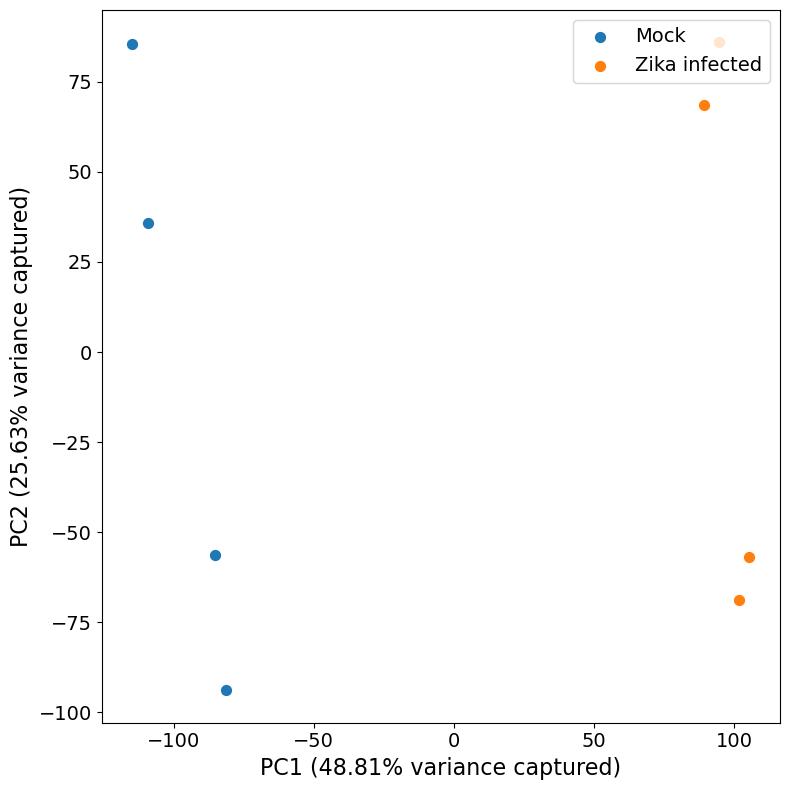

In [5]:
RNAseq.PCA_plot(expr_df.values, meta['infection_status'], standardize=2, log=True,
                legend_loc='upper right')

The same plot colored by sequencing platform.

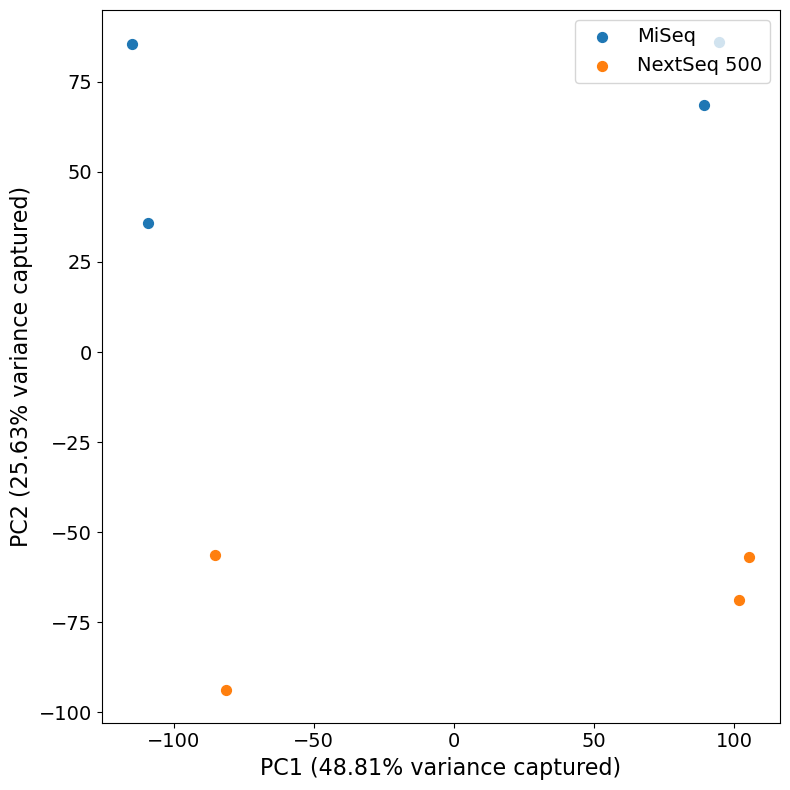

In [6]:
RNAseq.PCA_plot(expr_df.values, meta['platform'], standardize=2, log=True,
                legend_loc='upper right')

**Question:** Which factor separates the samples along PC1, and which along PC2? Why does this matter when we look for infection-related genes?

An interactive 3D version (drag to rotate, hover to see sample names):

In [7]:
import plotly.graph_objects as go

variance_explained, pca_coords = RNAseq.perform_PCA(expr_df.values, standardize=2, log=True)
pca_df = pd.DataFrame(pca_coords[:, :3], index=expr_df.columns, columns=['x', 'y', 'z']).join(meta)

fig = go.Figure()
for (status, platform), grp in pca_df.groupby(['infection_status', 'platform']):
    fig.add_trace(go.Scatter3d(
        x=grp['x'], y=grp['y'], z=grp['z'], text=grp['sample_name'], mode='markers',
        marker=dict(size=8, opacity=.8,
                    color=RNAseq.COLORS10[sorted(meta['infection_status'].unique()).index(status)],
                    symbol='circle' if platform == 'MiSeq' else 'square'),
        name='%s, %s' % (status, platform)))
fig.update_layout(height=700, title='3D PCA of samples',
                  scene=dict(xaxis_title='PC1 (%.1f%%)' % variance_explained[0],
                             yaxis_title='PC2 (%.1f%%)' % variance_explained[1],
                             zaxis_title='PC3 (%.1f%%)' % variance_explained[2]))
fig.show()

## 5. Hierarchical clustering of the most variable genes

We take the 800 genes with the largest variance, log-transform and z-score each gene, and cluster both genes and samples.

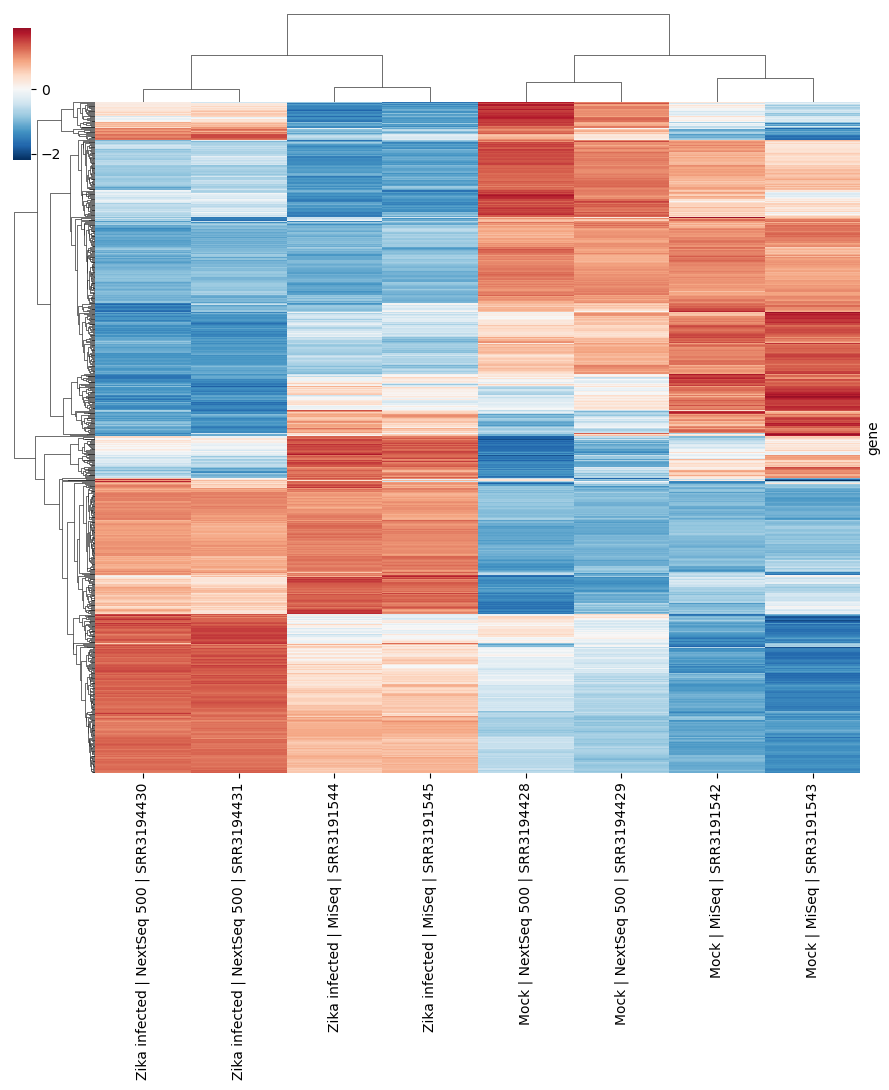

In [8]:
import seaborn as sns

top_genes = expr_df.var(axis=1).sort_values(ascending=False).index[:800]
heat = np.log1p(expr_df.loc[top_genes])
heat = heat.sub(heat.mean(axis=1), axis=0).div(heat.std(axis=1, ddof=0), axis=0)
heat.columns = ['%s | %s | %s' % (meta.loc[r, 'infection_status'], meta.loc[r, 'platform'], r)
                for r in heat.columns]

sns.clustermap(heat, cmap='RdBu_r', center=0, figsize=(9, 11), yticklabels=False,
               dendrogram_ratio=(.1, .12), cbar_pos=(.02, .85, .02, .12))
plt.show()

## 6. Differentially expressed genes: the Characteristic Direction

The [Characteristic Direction](https://pubmed.ncbi.nlm.nih.gov/24650281/) (CD) assigns every gene a coefficient: a large positive value means the gene goes up after infection, a large negative value means it goes down. We compute it for each platform separately and for all samples combined, then keep the 600 genes with the largest absolute coefficient as the "up" and "down" lists.

In [9]:
platforms = ['MiSeq', 'NextSeq 500']
sample_classes = {}
for platform in platforms:
    on_platform = (meta['platform'] == platform).values
    infected = (meta['infection_status'] == 'Zika infected').values
    cls = np.zeros(len(meta), dtype=int)   # 0 = not used in this comparison
    cls[on_platform] = 1                   # 1 = control
    cls[on_platform & infected] = 2        # 2 = infected
    sample_classes[platform] = cls
sample_classes['combined'] = sample_classes['MiSeq'] + sample_classes['NextSeq 500']

cd_results = pd.DataFrame(index=expr_df.index)
gene_lists = {}
for name, cls in sample_classes.items():
    coefs = RNAseq.chdir(expr_df.values, cls, gamma=.5)
    cd_results[name] = coefs
    top = np.abs(coefs).argsort()[::-1][:600]
    genes, vals = expr_df.index[top], coefs[top]
    gene_lists[name + '-up'] = genes[vals > 0].tolist()
    gene_lists[name + '-dn'] = genes[vals < 0].tolist()

print({k: len(v) for k, v in gene_lists.items()})
cd_results.sort_values('combined').head()

{'MiSeq-up': 335, 'MiSeq-dn': 265, 'NextSeq 500-up': 330, 'NextSeq 500-dn': 270, 'combined-up': 212, 'combined-dn': 388}


,MiSeq,NextSeq 500,combined
gene,,,
MAP4K4,-0.009023,-0.008149,-0.010447
PRR29,-0.009030,-0.008171,-0.010441
ZNF512,-0.009025,-0.008169,-0.010435
RAB30-DT,-0.009034,-0.008139,-0.010425
CLXN,-0.009009,-0.008166,-0.010420


How similar are the signatures from the two platforms? A cosine distance of 0 means identical direction and 1 means unrelated.

In [10]:
from itertools import combinations
from scipy.spatial.distance import cosine

for a, b in combinations(cd_results.columns, 2):
    print(a, 'vs', b, ': cosine distance = %.3f' % cosine(cd_results[a], cd_results[b]))

MiSeq vs NextSeq 500 : cosine distance = 0.163
MiSeq vs combined : cosine distance = 0.058
NextSeq 500 vs combined : cosine distance = 0.069


## 7. Enrichment analysis with Enrichr

[Enrichr](https://maayanlab.cloud/Enrichr/) compares a gene list with thousands of annotated gene sets (pathways, transcription-factor targets, mouse knockout phenotypes, ...) and reports which are over-represented.

To keep this notebook fast and independent of the web service, the Enrichr results for our six gene lists were **saved in `data/enrichr/`**. The cell below loads them. Each link opens the full interactive Enrichr results for that gene list.

In [11]:
from IPython.display import HTML, display

with open('data/enrichr/gene_list_links.json') as f:
    enrichr_links = json.load(f)

links_df = pd.DataFrame(enrichr_links).T
links_df['url'] = links_df['url'].apply(lambda u: '<a href="%s" target="_blank">open in Enrichr</a>' % u)
display(HTML(links_df.to_html(escape=False)))

,n_genes,url
MiSeq-up,335,open in Enrichr
MiSeq-dn,265,open in Enrichr
NextSeq 500-up,330,open in Enrichr
NextSeq 500-dn,270,open in Enrichr
combined-up,212,open in Enrichr
combined-dn,388,open in Enrichr


In [12]:
# To re-run Enrichr yourself (needs internet; Enrichr limits request rates, so wait between calls):
# for name, genes in gene_lists.items():
#     print(name, RNAseq.enrichr_link(genes, name))

### Genes that go down after infection

The down-regulated genes are enriched for cell-cycle processes, reported in the original study. Here are the top DNA-replication/cell-cycle pathways (KEGG) and the transcription factors whose targets are enriched (ChEA).

In [13]:
def load_enrichr(library, gene_list):
    with open('data/enrichr/%s_%s.json' % (library, gene_list)) as f:
        res = pd.DataFrame(json.load(f)['results']).set_index('rank')
    res['genes'] = res['genes'].apply(lambda g: ', '.join(g))
    return res

load_enrichr('KEGG_2016', 'combined-dn')[['term', 'p_value', 'combined_score', 'genes']]

,term,p_value,combined_score,genes
rank,,,,
1,DNA replication Homo sapiens hsa03030,1.973915e-12,702.016260,"POLD3, RNASEH2C, POLA1, FEN1, RFC3, PCNA, RFC4..."
2,Mismatch repair Homo sapiens hsa03430,7.095891e-09,516.088711,"POLD3, MSH6, RFC3, PCNA, RFC4, EXO1, RPA1, RPA2"
3,Cell cycle Homo sapiens hsa04110,5.416527e-06,67.379774,"CCNB2, CCNB1, TFDP1, PCNA, PTTG1, BUB1B, MCM4,..."
4,Fanconi anemia pathway Homo sapiens hsa03460,7.001943e-05,74.762042,"FANCI, FANCD2, FANCL, RPA1, RPA2, FANCC, BRCA1"
5,Nucleotide excision repair Homo sapiens hsa03420,2.812117e-04,61.302662,"POLD3, RFC3, PCNA, RFC4, RPA1, RPA2"
6,Base excision repair Homo sapiens hsa03410,4.062797e-04,71.298513,"POLD3, FEN1, PCNA, PARP1, UNG"
7,One carbon pool by folate Homo sapiens hsa00670,5.282064e-04,96.270751,"DHFR, MTHFD1, TYMS, GART"
8,HTLV-I infection Homo sapiens hsa05166,5.476724e-04,22.314218,"RANBP1, JUN, PCNA, FZD4, PIK3R3, WNT8B, BUB1B,..."
9,Pyrimidine metabolism Homo sapiens hsa00240,1.012999e-03,29.202997,"POLD3, POLA1, ENTPD1, RRM2, ENTPD4, TK2, CTPS1..."


In [14]:
load_enrichr('ChEA_2016', 'combined-dn')[['term', 'p_value', 'combined_score']]

,term,p_value,combined_score
rank,,,
1,E2F4 17652178 ChIP-ChIP JURKAT Human,9.487286e-12,80.789251
2,E2F7 22180533 ChIP-Seq HELA Human,5.152286e-11,435.340882
3,FOXM1 23109430 ChIP-Seq U2OS Human,2.967923e-07,64.042525
4,FOXM1 25889361 ChIP-Seq OE33 AND U2OS Human,2.339164e-06,31.276509
5,AR 21909140 ChIP-Seq LNCAP Human,6.380901e-06,42.680882
6,E2F1 21310950 ChIP-Seq MCF-7 Human,2.655948e-05,22.057437
7,E2F4 21247883 ChIP-Seq LYMPHOBLASTOID Human,9.397700e-05,15.142989
8,KDM5B 21448134 ChIP-Seq MESCs Mouse,1.504996e-03,9.413492
9,TRP63 18441228 ChIP-ChIP KERATINOCYTES Mouse,1.931482e-03,21.571775


**Question:** E2F4 and FOXM1 are regulators of cell division. What does it mean that their target genes go down after Zika infection, and how could that relate to microcephaly?

### Genes that go up after infection

For the up-regulated genes we ask which mouse knockout phenotypes (MGI Mammalian Phenotype library) are enriched. Look for brain-related terms such as *abnormal brain morphology*. Each gene links to [Harmonizome](https://maayanlab.cloud/Harmonizome/).

In [15]:
def genes_to_links(genes, per_line=6):
    html = ''
    for i, g in enumerate(genes, start=1):
        html += '<a href="https://maayanlab.cloud/Harmonizome/gene/%s" target="_blank">%s</a>' % (g, g)
        html += '<br>' if i % per_line == 0 else ', '
    return html

mgi = pd.DataFrame(json.load(open('data/enrichr/MGI_Mammalian_Phenotype_Level_4_combined-up.json'))['results'])
mgi['genes'] = mgi['genes'].apply(genes_to_links)
mgi = mgi.set_index('rank')[['term', 'p_value', 'combined_score', 'genes']]
display(HTML(mgi.to_html(escape=False, float_format=lambda x: '%.2e' % x, justify='left')))

,term,p_value,combined_score,genes
rank,,,,
1,MP0005076 abnormal cell differentiation,2.71e-04,1.20e+02,"CEBPB, IRS1, NCOA3, IRS2,"
2,MP0003948 abnormal gas homeostasis,5.07e-04,2.70e+01,"MN1, KLF7, XBP1, HSPA5, NCOA3, AKAP8SAFB, PPARGC1A, ABCG1, IGF2R, VEGFA,"
3,MP0006138 congestive heart failure,2.74e-03,4.39e+01,"TIMP3, ADRA1A, PPARGC1A, IGF2R,"
4,MP0010769 abnormal survival,2.85e-03,1.15e+01,"NRP2, CEBPB, PCDH10, IRS1, CELF1, NCOA3SPRY4, AKAP8, TNFAIP3, TBR1, TSC1, SHISA2IGF2R, CRKL, VEGFA, SMAD7, KLF7, PCLOHERC1, HEY1, SPRY2, PPARGC1A, SOCS7, UNC79"
5,MP0010768 mortality/aging,3.72e-03,1.08e+01,"NRP2, CEBPB, PCDH10, IRS1, CELF1, NCOA3SPRY4, AKAP8, TNFAIP3, TBR1, TSC1, SHISA2IGF2R, CRKL, VEGFA, SMAD7, KLF7, PCLOHERC1, HEY1, SPRY2, PPARGC1A, SOCS7, UNC79"
6,MP0002082 postnatal lethality,3.73e-03,1.11e+01,"NRP2, CEBPB, PCDH10, IRS1, CELF1, NCOA3SPRY4, AKAP8, TNFAIP3, TBR1, TSC1, SHISA2IGF2R, CRKL, VEGFA, SMAD7, KLF7, HEY1SPRY2, PPARGC1A, SOCS7, UNC79,"
7,MP0010770 preweaning lethality,3.77e-03,1.11e+01,"NRP2, CEBPB, PCDH10, IRS1, CELF1, NCOA3SPRY4, AKAP8, TNFAIP3, TBR1, TSC1, SHISA2IGF2R, CRKL, VEGFA, SMAD7, KLF7, HEY1SPRY2, PPARGC1A, SOCS7, UNC79,"
8,MP0005165 increased susceptibility to,7.20e-03,2.75e+01,"TIMP3, HYOU1, ADRA1A, PPARGC1A,"
9,MP0002152 abnormal brain morphology,7.81e-03,8.97e+00,"NRP2, PCDH10, SMURF1, TBR1, TSC1, IRS2SHISA2, HSD17B7, IGF2R, VEGFA, MECP2, KLF7NR4A3, HERC1, HEY1, NPC1, ATXN7, SPRY2HYOU1, SP8, PPARGC1A, SOCS7,"


In [16]:
# Live version of the query above (needs internet):
# library = 'MGI_Mammalian_Phenotype_Level_4'
# live = RNAseq.enrichr_result(gene_lists['combined-up'], gmt=library)[library]
# live = pd.DataFrame(live, columns=['rank', 'term', 'p_value', 'zscore', 'combined_score',
#                                    'genes', 'adj_p_value', 'old_p_value', 'old_adj_p_value']).set_index('rank')
# live.head(10)

## 8. Finding small molecules with L1000CDS2

[L1000CDS2](https://maayanlab.cloud/L1000CDS2/) searches the LINCS L1000 database of drug-induced expression signatures for molecules whose signature is similar to ours (**mimickers**) or opposite to it (**reversers**). The opposite ones are candidates that might counteract the infection.

Results for each signature were saved in `data/l1000cds2/`.

In [17]:
def load_cds2(signature, kind):
    with open('data/l1000cds2/%s_%s.json' % (signature.replace(' ', '_'), kind)) as f:
        res = json.load(f)
    df = pd.DataFrame(res['top'])[['pert_desc', 'cell_id', 'pert_dose', 'pert_dose_unit', 'pert_time', 'score']]
    return res['url'], df

for kind in ['mimickers', 'reversers']:
    url, df = load_cds2('combined', kind)
    print('combined', kind, '- full results:', url)
    display(df)

combined mimickers - full results: https://maayanlab.cloud/L1000CDS2/#/result/6ac6819dff05f50052ad9882


,pert_desc,cell_id,pert_dose,pert_dose_unit,pert_time,score
0,PERHEXILINE MALEATE,HT29,10.0,um,24.0,0.4839
1,-666,HT29,10.0,um,24.0,0.4884
2,Akt inhibitor IV,HT29,10.0,um,24.0,0.4915
3,-666,HCC515,40.0,um,24.0,0.4950
4,-666,A375,11.1,um,24.0,0.4956
5,CGP 71683 hydrochloride,HCC515,10.0,um,24.0,0.4998
6,Ro 28-1675 ?,A375,160.0,um,24.0,0.5003
7,-666,MCF7,11.1,um,24.0,0.5022
8,-666,MCF7,10.0,um,24.0,0.5024
9,Chemistry 2804,MCF7,10.0,um,24.0,0.5027


combined reversers - full results: https://maayanlab.cloud/L1000CDS2/#/result/6ac681a7ff05f50052ad9884


,pert_desc,cell_id,pert_dose,pert_dose_unit,pert_time,score
0,-666,ASC,10.0,um,24.0,1.2700
1,am 404,VCAP,10.0,um,24.0,1.2633
2,nifedipine,VCAP,10.0,um,24.0,1.2573
3,CGP-60474,HME1,0.12,um,3,1.2539
4,"6-methoxy-2,3,4,9-tetrahydro-1H-pyrido[3,4-b]i...",VCAP,10.0,um,24.0,1.2534
5,NCGC00012272-02,VCAP,10.0,um,24.0,1.2524
6,AT-7519,HME1,1.11,um,3,1.2441
7,dasatinib,HA1E,0.12,um,24,1.2413
8,dasatinib,HA1E,0.12,um,24,1.2384
9,PF-562271,HME1,10,um,3,1.2369


In [18]:
# Live version (needs internet; returns a share link to the full results):
# res = RNAseq.post_to_cds2(genes, vals, name='combined', aggravate=True)   # True = mimickers, False = reversers
# print('https://maayanlab.cloud/L1000CDS2/#/result/' + res['shareId'])
# where genes/vals are the 2000 genes with the largest |CD coefficient|:
# top = np.abs(cd_results['combined']).sort_values(ascending=False).index[:2000]
# genes, vals = top.tolist(), cd_results.loc[top, 'combined'].tolist()

Results for the MiSeq and NextSeq signatures are available as `load_cds2('MiSeq', 'mimickers')` and so on.

## 9. Exercises

1. In the PCA plots, which principal component reflects infection and which reflects the sequencing platform? Estimate how much variance each explains.
2. Re-run Section 6 using only the MiSeq samples. How many genes do the MiSeq and NextSeq "down" lists share? (`set(gene_lists['MiSeq-dn']) & set(gene_lists['NextSeq 500-dn'])`)
3. Pick one gene from the combined "up" list and plot its CPM in all 8 samples. Is the change consistent across platforms?
4. Choose one L1000CDS2 reverser. What is known about this compound, and would you expect it to be useful against Zika? Why or why not?

## References

1. Tang, H. et al. (2016) Zika virus infects human cortical neural progenitors and attenuates their growth. *Cell Stem Cell*.
2. Clark, N.R. et al. (2014) The characteristic direction: a geometrical approach to identify differentially expressed genes. *BMC Bioinformatics* 15:79.
3. Chen, E.Y. et al. (2013) Enrichr: interactive and collaborative HTML5 gene list enrichment analysis tool. *BMC Bioinformatics* 14:128.
4. Duan, Q. et al. (2016) L1000CDS2: LINCS L1000 characteristic direction signatures search engine. *npj Systems Biology and Applications* 2:16015.
5. Wang, Z. and Ma'ayan, A. (2016) An open RNA-Seq data analysis pipeline tutorial with an example of reprocessing data from a recent Zika virus study. *F1000Research* 5:1574.